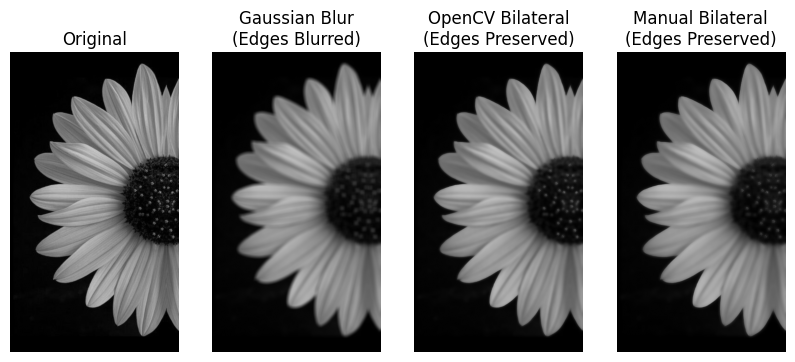

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_bilateral_filter(image, diameter, sigma_s, sigma_r):

    h, w = image.shape
    output = np.zeros((h, w), dtype=np.float32)
    radius = diameter // 2
    
    # Pad the image to handle edges
    padded_img = np.pad(image, radius, mode='edge').astype(np.float32)
    
    # Pre compute spatial Gaussian weights
    y, x = np.ogrid[-radius : radius + 1, -radius : radius + 1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

    for i in range(h):
        for j in range(w):
            # Extract the local neighborhood (region of interest)
            roi = padded_img[i : i + diameter, j : j + diameter]
            
            # Calculate range weights (intensity difference)
            center_pixel = padded_img[i + radius, j + radius]
            intensity_diff = roi - center_pixel
            range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))
            
            # Combined weights
            bilateral_weights = spatial_weights * range_weights
            
            # Normalize and apply weights
            normalization_factor = np.sum(bilateral_weights)
            output[i, j] = np.sum(bilateral_weights * roi) / normalization_factor
            
    return output.astype(np.uint8)

im = cv2.imread('images/a1images/sunflower.jpg', cv2.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

d = 9 # Kernel diameter
s_space = 75.0 # Spatial sigma
s_range = 75.0 # Intensity sigma

# (b) Apply Gaussian Smoothing
gaussian_blur = cv2.GaussianBlur(im, (d, d), s_space)

# (c) Bilateral filtering using OpenCV
opencv_bilateral = cv2.bilateralFilter(im, d, s_range, s_space)

# (d) Manually implemented bilateral filter
manual_bilateral = manual_bilateral_filter(im, d, s_space, s_range)

fig, ax = plt.subplots(1, 4, figsize=(10, 5))

ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(gaussian_blur, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Gaussian Blur\n(Edges Blurred)')
ax[1].axis('off')

ax[2].imshow(opencv_bilateral, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('OpenCV Bilateral\n(Edges Preserved)')
ax[2].axis('off')

ax[3].imshow(manual_bilateral, cmap='gray', vmin=0, vmax=255)
ax[3].set_title('Manual Bilateral\n(Edges Preserved)')
ax[3].axis('off')

plt.show()